In [1]:
%cd ..


/home/maxim/projects/sandbox/cloud-ivan


# DEV

## 1. EDA-анализ данных

In [6]:
!pip install kagglehub pandas matplotlib opencv-python


  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 10.5 MB/s eta 0:00:00a 0:00:01
Usi

In [9]:
import kagglehub
import shutil
from pathlib import Path

# Определяем наши константы путей
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "dataset"
DATASET_NAME = "muhammetzahitaydn/hardhat-vest-dataset-v3"

def setup_dataset():
    """Скачивает датасет через kagglehub и интегрирует в локальную структуру проекта."""
    print("[*] Обращение к Kaggle API...")
    
    # kagglehub сам разберется с токенами (если они настроены) и скачает данные в кэш
    cache_path = kagglehub.dataset_download(DATASET_NAME)
    print(f"[+] Данные успешно загружены в системный кэш: {cache_path}")
    
    # Проверяем, перенесли ли мы уже данные в нашу рабочую папку
    if DATA_DIR.exists():
        print(f"[+] Данные уже находятся в рабочей директории проекта: {DATA_DIR}")
        return
        
    print(f"[*] Копируем данные из кэша в структуру проекта {DATA_DIR}...")
    # Копируем всё содержимое из системного кэша в нашу папку
    shutil.copytree(cache_path, DATA_DIR)
    
    print("[+] Архитектурная целостность сохранена. Данные готовы к работе.")

# Запускаем процесс
setup_dataset()


[*] Обращение к Kaggle API...
[+] Данные успешно загружены в системный кэш: /root/.cache/kagglehub/datasets/muhammetzahitaydn/hardhat-vest-dataset-v3/versions/2
[*] Копируем данные из кэша в структуру проекта /home/maxim/projects/sandbox/cloud-ivan/data/dataset...
[+] Архитектурная целостность сохранена. Данные готовы к работе.


[*] Анализируем структуру и классы...
--- Статистика по выборкам ---
Split  Images  Labels  Helmet (0)  Vest (1)  Head (2)
train   15005   17248       43905      6326     98256
  val    1965    2438        6586       870     13576
 test    1980    2455        6749       935     12509


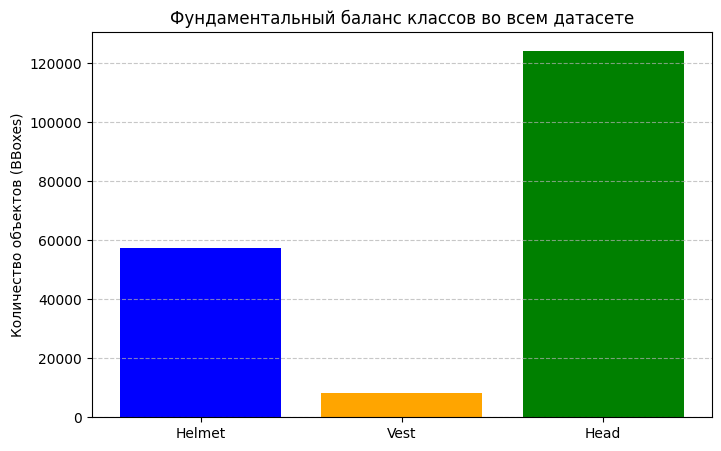

In [14]:
import glob
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Маппинг классов на основе описания датасета
CLASS_NAMES = {0: 'Helmet', 1: 'Vest', 2: 'Head'}

def analyze_dataset_splits(data_path: Path):
    """Анализ количества файлов и баланса классов по сплитам (train, val, test)."""
    splits = ['train', 'val', 'test'] # Зависит от структуры внутри архива, проверим
    stats = []
    class_distribution = Counter()

    for split in splits:
        split_img_dir = data_path / split / "images"
        split_lbl_dir = data_path / split / "labels"
        
        # Если структура папок отличается, попробуем альтернативный путь (часто бывает в YOLO датасетах)
        if not split_img_dir.exists():
             split_img_dir = data_path / "images" / split
             split_lbl_dir = data_path / "labels" / split
             
        if not split_img_dir.exists():
            continue

        images = glob.glob(str(split_img_dir / "*.jpg"))
        labels = glob.glob(str(split_lbl_dir / "*.txt"))
        
        # Читаем все txt файлы для подсчета классов
        split_classes = Counter()
        for label_path in labels:
            with open(label_path, 'r') as f:
                for line in f:
                    class_id = int(line.split()[0])
                    split_classes[class_id] += 1
                    class_distribution[class_id] += 1
                    
        stats.append({
            "Split": split,
            "Images": len(images),
            "Labels": len(labels),
            "Helmet (0)": split_classes.get(0, 0),
            "Vest (1)": split_classes.get(1, 0),
            "Head (2)": split_classes.get(2, 0)
        })

    df = pd.DataFrame(stats)
    print("--- Статистика по выборкам ---")
    print(df.to_string(index=False))
    
    return class_distribution

print("[*] Анализируем структуру и классы...")
total_distribution = analyze_dataset_splits(DATA_DIR)

# Визуализация дисбаланса
plt.figure(figsize=(8, 5))
plt.bar([CLASS_NAMES[i] for i in total_distribution.keys()], total_distribution.values(), color=['blue', 'orange', 'green'])
plt.title("Фундаментальный баланс классов во всем датасете")
plt.ylabel("Количество объектов (BBoxes)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


[*] Генерируем визуальную сетку...


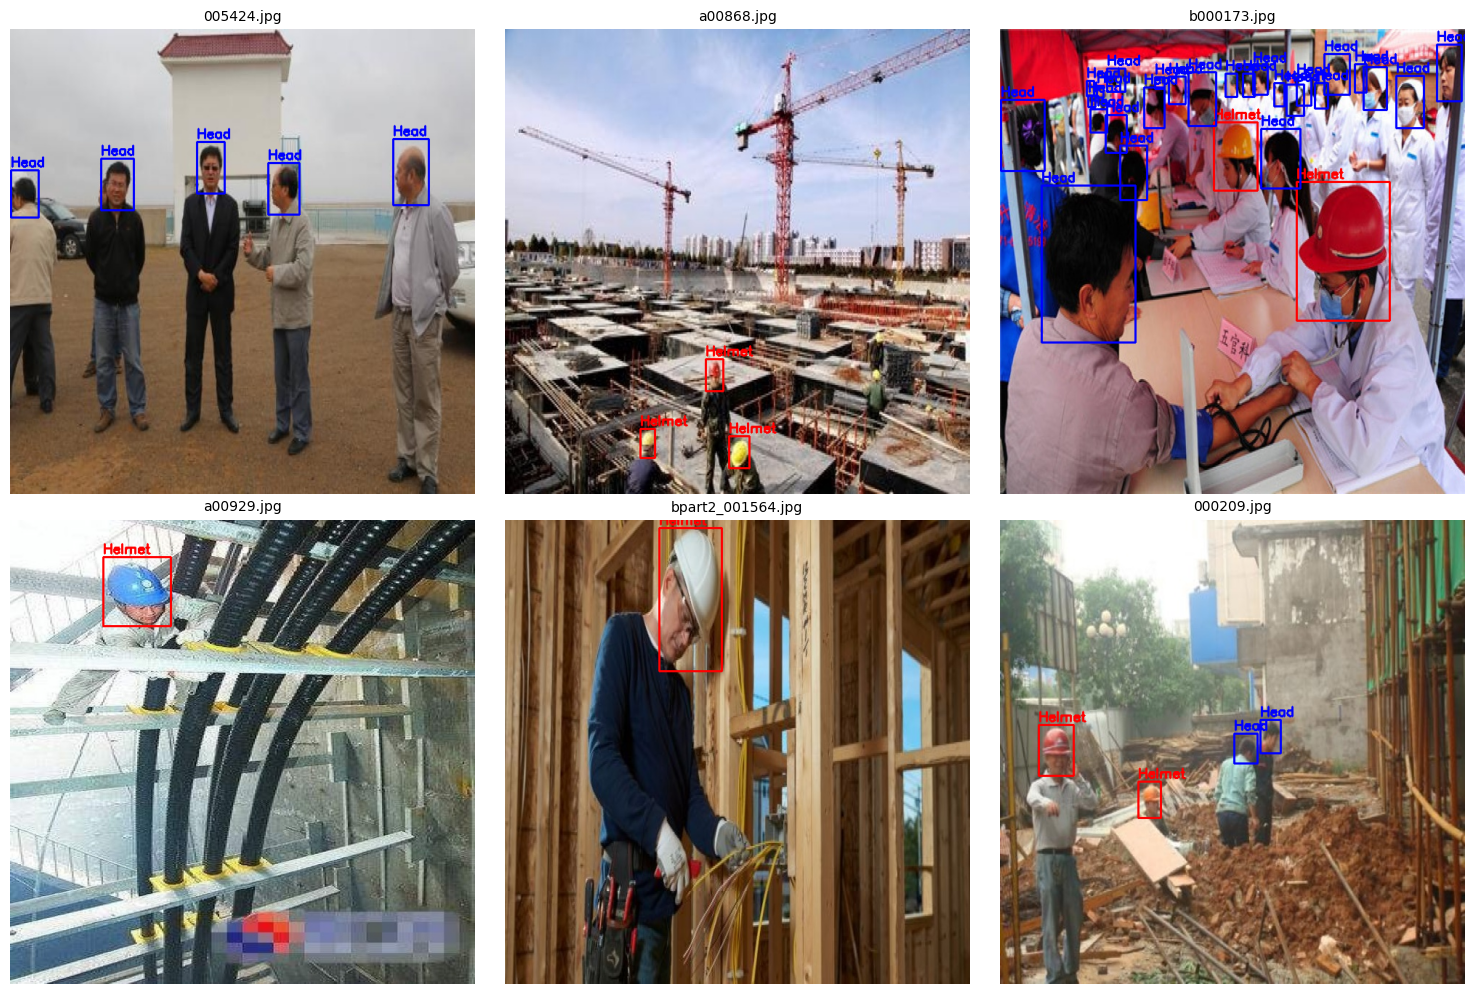

In [11]:
import cv2
import random
import numpy as np

def visualize_random_samples(data_path: Path, num_samples: int = 6):
    """Вывод сетки изображений с отрисованными BBox."""
    # Ищем все изображения в обучающей выборке
    img_dir = data_path / "train" / "images"
    lbl_dir = data_path / "train" / "labels"
    
    if not img_dir.exists():
         img_dir = data_path / "images" / "train"
         lbl_dir = data_path / "labels" / "train"

    all_images = list(img_dir.glob("*.jpg"))
    if not all_images:
        print("Изображения не найдены. Проверь пути распаковки.")
        return

    # Выбираем случайные изображения
    samples = random.sample(all_images, min(num_samples, len(all_images)))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = {0: (255, 0, 0), 1: (0, 255, 0), 2: (0, 0, 255)} # RGB для matplotlib
    
    for ax, img_path in zip(axes, samples):
        # Читаем картинку
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        
        # Ищем соответствующий файл разметки
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        
        if lbl_path.exists():
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, w, h = map(float, parts[1:])
                    
                    # Денормализация координат (наша формула)
                    xmin = int((x_center - w / 2) * W)
                    ymin = int((y_center - h / 2) * H)
                    xmax = int((x_center + w / 2) * W)
                    ymax = int((y_center + h / 2) * H)
                    
                    # Рисуем рамку и текст
                    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), colors.get(class_id, (255,255,255)), 2)
                    cv2.putText(img, CLASS_NAMES[class_id], (xmin, ymin - 5), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors.get(class_id, (255,255,255)), 2)
                    
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_path.name, fontsize=10)
        
    plt.tight_layout()
    plt.show()

print("[*] Генерируем визуальную сетку...")
visualize_random_samples(DATA_DIR)


## 2. Обучение YOLO

In [15]:
!pip install ultralytics


  Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached torchvision-0.25.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_

In [18]:
import yaml
from pathlib import Path

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "dataset"
YAML_PATH = DATA_DIR / "data.yaml"

def create_yolo_yaml(data_path: Path, yaml_path: Path):
    """Умная генерация конфигурации с проверкой структуры директорий."""
    
    # Определяем реальную структуру папок
    if (data_path / "images" / "train").exists():
        print("[*] Обнаружена структура Тип Б (images/train)")
        train_path = 'images/train'
        val_path = 'images/val'
        test_path = 'images/test'
    else:
        print("[*] Обнаружена структура Тип А (train/images)")
        train_path = 'train/images'
        val_path = 'val/images'
        test_path = 'test/images'

    yaml_content = {
        'path': str(data_path.absolute()),
        'train': train_path,
        'val': val_path,
        'test': test_path,
        'names': {0: 'Helmet', 1: 'Vest', 2: 'Head'}
    }
    
    with open(yaml_path, 'w', encoding='utf-8') as f:
        yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)
        
    print(f"[+] Конфигурация YOLO успешно обновлена: {yaml_path}")

create_yolo_yaml(DATA_DIR, YAML_PATH)


[*] Обнаружена структура Тип Б (images/train)
[+] Конфигурация YOLO успешно обновлена: /home/maxim/projects/sandbox/cloud-ivan/data/dataset/data.yaml


In [2]:
from ultralytics import YOLO
import torch
from pathlib import Path

BASE_DIR = Path.cwd()
YAML_PATH = BASE_DIR / "data" / "dataset" / "data.yaml"
MODELS_DIR = BASE_DIR / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints"
RUNS_DIR = MODELS_DIR / "runs"

def train_yolo_model_v2(yaml_path: Path):
    # Очистка кэша CUDA перед стартом, чтобы сбросить "зависшую" память от прошлого падения
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        device = '0'
        print(f"[*] Выявлен GPU CUDA: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        device = 'mps'
    else:
        device = 'cpu'

    base_model_path = CHECKPOINTS_DIR / 'yolov8n.pt'
    model = YOLO(str(base_model_path)) 

    print("\n[*] СТАРТ ОБУЧЕНИЯ (V2: Оптимизация памяти)...")
    results = model.train(
        data=str(yaml_path),
        epochs=10,
        imgsz=640,
        batch=8,           # [ИЗМЕНЕНО] Снижаем нагрузку на VRAM в 2 раза
        workers=4,         # [ИЗМЕНЕНО] Уменьшаем количество потоков подготовки данных
        device=device,
        project=str(RUNS_DIR), 
        name='hardhat_v2', # [ИЗМЕНЕНО] Новая папка для чистого эксперимента
        exist_ok=True,
        verbose=True
    )
    
    best_weights_path = RUNS_DIR / 'hardhat_v2' / 'weights' / 'best.pt'
    print(f"\n[+] Обучение завершено. Ищи лучшие веса здесь: {best_weights_path}")
    
    return results

train_yolo_model_v2(YAML_PATH)


[*] Выявлен GPU CUDA: NVIDIA GeForce RTX 3060

[*] СТАРТ ОБУЧЕНИЯ (V2: Оптимизация памяти)...
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/maxim/projects/sandbox/cloud-ivan/data/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/home/maxim/projects/sandbox/cloud-ivan

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78359acf01a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
import cv2
from pathlib import Path
from ultralytics import YOLO

# Пути
BASE_DIR = Path.cwd()
TEST_DATA_DIR = BASE_DIR / "data" / "test"
RESULTS_DIR = BASE_DIR / "data" / "results"
WEIGHTS_PATH = BASE_DIR / "models" / "runs" / "hardhat_v2" / "weights" / "best.pt"

# Создаем папку для результатов
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "img").mkdir(exist_ok=True)
(RESULTS_DIR / "vid").mkdir(exist_ok=True)

def run_inference_on_test_data(weights_path: Path, test_dir: Path, results_dir: Path):
    """Прогоняет инференс на тестовых фото и видео."""
    print(f"[*] Загрузка модели: {weights_path}")
    model = YOLO(str(weights_path))
    
    # 1. Инференс для изображений
    img_dir = test_dir / "img"
    if img_dir.exists():
        print("[*] Обработка изображений...")
        for img_path in img_dir.glob("*.jpg"):
            # Запускаем модель (conf=0.5 значит, что мы берем только те предсказания, 
            # в которых модель уверена на 50% и более)
            results = model(str(img_path), conf=0.5, verbose=False)
            
            # Отрисовываем результаты на изображении
            annotated_img = results[0].plot()
            
            # Сохраняем результат
            save_path = results_dir / "img" / f"res_{img_path.name}"
            cv2.imwrite(str(save_path), annotated_img)
            print(f"  [+] Сохранено: {save_path.name}")
            
    # 2. Инференс для видео
    vid_dir = test_dir / "vid"
    if vid_dir.exists():
        print("\n[*] Обработка видео (может занять время)...")
        for vid_path in vid_dir.glob("*.mp4"):
            # Для видео мы используем генератор, чтобы не грузить всю память
            results = model(str(vid_path), stream=True, conf=0.5, verbose=False)
            
            # Настройка VideoWriter для сохранения результата
            cap = cv2.VideoCapture(str(vid_path))
            fps = int(cap.get(cv2.CAP_PROP_FPS))
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Временный кодек для OpenCV
            
            save_path = results_dir / "vid" / f"res_{vid_path.name}"
            out = cv2.VideoWriter(str(save_path), fourcc, fps, (width, height))
            
            for r in results:
                annotated_frame = r.plot()
                out.write(annotated_frame)
                
            cap.release()
            out.release()
            print(f"  [+] Сохранено видео: {save_path.name}")

run_inference_on_test_data(WEIGHTS_PATH, TEST_DATA_DIR, RESULTS_DIR)


[*] Загрузка модели: /home/maxim/projects/sandbox/cloud-ivan/models/runs/hardhat_v2/weights/best.pt
[*] Обработка изображений...
  [+] Сохранено: res_000988.jpg
  [+] Сохранено: res_001563.jpg
  [+] Сохранено: res_001200.jpg
  [+] Сохранено: res_001283.jpg
  [+] Сохранено: res_001168.jpg
  [+] Сохранено: res_000655.jpg
  [+] Сохранено: res_000454.jpg
  [+] Сохранено: res_000036.jpg
  [+] Сохранено: res_001041.jpg
  [+] Сохранено: res_000700.jpg
  [+] Сохранено: res_001628.jpg
  [+] Сохранено: res_001148.jpg
  [+] Сохранено: res_000928.jpg
  [+] Сохранено: res_000674.jpg
  [+] Сохранено: res_000374.jpg
  [+] Сохранено: res_001597.jpg
  [+] Сохранено: res_000874.jpg

[*] Обработка видео (может занять время)...
  [+] Сохранено видео: res_1.mp4
  [+] Сохранено видео: res_3.mp4
  [+] Сохранено видео: res_2.mp4
  [+] Сохранено видео: res_30sec.mp4
  [+] Сохранено видео: res_20sec.mp4


In [4]:
from ultralytics import YOLO
from pathlib import Path

BASE_DIR = Path.cwd()
WEIGHTS_PATH = BASE_DIR / "models" / "runs" / "hardhat_v2" / "weights" / "best.pt"

def export_to_onnx(weights_path: Path):
    """Отвязываем модель от PyTorch и превращаем в статический граф ONNX."""
    print(f"[*] Загрузка динамического графа PyTorch из: {weights_path}")
    
    # Загружаем нашу лучшую модель
    model = YOLO(str(weights_path))
    
    print("[*] Запуск конвертации в ONNX. Выполняется трассировка и оптимизация графа...")
    
    # Экспорт. 
    # imgsz=640 фиксирует размер входного тензора.
    # simplify=True включает ONNX Simplifier (убирает избыточные операции).
    exported_path = model.export(
        format='onnx',
        imgsz=640,
        simplify=True, 
        opset=12  # Версия стандарта операций (12-я стабильна для большинства сред)
    )
    
    print(f"\n[+] Фундаментальный переход завершен.")
    print(f"[+] Статическая ONNX модель готова: {exported_path}")
    return exported_path

export_to_onnx(WEIGHTS_PATH)


[*] Загрузка динамического графа PyTorch из: /home/maxim/projects/sandbox/cloud-ivan/models/runs/hardhat_v2/weights/best.pt
[*] Запуск конвертации в ONNX. Выполняется трассировка и оптимизация графа...
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (11th Gen Intel Core i7-11700KF @ 3.60GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/home/maxim/projects/sandbox/cloud-ivan/models/runs/hardhat_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/17.5 MB ? eta -:--:--
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/17.5 MB ? eta -:--:--
   ━━━╸━━━

'/home/maxim/projects/sandbox/cloud-ivan/models/runs/hardhat_v2/weights/best.onnx'

In [8]:
import cv2
import numpy as np
from pathlib import Path

class YoloONNX:
    """
    Минималистичный класс для инференса YOLOv8-ONNX через OpenCV DNN.
    Без зависимостей от PyTorch и Ultralytics.
    """
    def __init__(self, onnx_path: str | Path, conf_threshold: float = 0.5, iou_threshold: float = 0.4):
        self.onnx_path = str(onnx_path)
        self.conf_threshold = conf_threshold
        self.iou_threshold = iou_threshold
        
        self.classes = {0: 'Helmet', 1: 'Vest', 2: 'Head'}
        self.colors = {
            0: (255, 0, 0),   # Helmet - Синий (OpenCV использует BGR)
            1: (0, 255, 0),   # Vest - Зеленый
            2: (0, 0, 255)    # Head - Красный
        }
        
        print(f"[*] Инициализация cv2.dnn. Загрузка графа: {Path(self.onnx_path).name}")
        self.net = cv2.dnn.readNetFromONNX(self.onnx_path)
        
        # Жестко фиксируем выполнение на CPU. 
        # Это гарантирует, что код будет работать на любом сервере/контейнере из коробки.
        self.net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        self.net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
        print("  [*] DNN Backend: OpenCV (CPU)")

    def _prepare_input(self, image: np.ndarray) -> tuple[np.ndarray, float, float]:
        """Предобработка: ресайз с сохранением пропорций (letterbox) и нормализация."""
        # YOLOv8 ждет квадратное изображение 640x640
        input_size = 640
        shape = image.shape[:2]
        
        # Вычисляем масштаб
        scale = min(input_size / shape[0], input_size / shape[1])
        new_shape = (int(shape[1] * scale), int(shape[0] * scale))
        
        # Ресайз
        resized_img = cv2.resize(image, new_shape, interpolation=cv2.INTER_LINEAR)
        
        # Добавляем паддинг (серые полосы), чтобы получить ровно 640x640
        pad_w = (input_size - new_shape[0]) / 2
        pad_h = (input_size - new_shape[1]) / 2
        
        top, bottom = int(round(pad_h - 0.1)), int(round(pad_h + 0.1))
        left, right = int(round(pad_w - 0.1)), int(round(pad_w + 0.1))
        
        padded_img = cv2.copyMakeBorder(resized_img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=(114, 114, 114))
        
        # Конвертация в блоб для сети: BGR->RGB, нормализация [0-1] (1/255.0)
        blob = cv2.dnn.blobFromImage(padded_img, 1/255.0, (input_size, input_size), swapRB=True, crop=False)
        
        return blob, scale, pad_w, pad_h

    def _postprocess(self, output_tensor: np.ndarray, orig_shape: tuple, scale: float, pad_w: float, pad_h: float) -> list:
        """Сложнейший этап: разбор сырого тензора YOLOv8 (1, 7, 8400)."""
        # YOLOv8 отдает матрицу [1, 7, 8400]. 
        # 7 = [x_center, y_center, width, height, conf_class_0, conf_class_1, conf_class_2]
        # 8400 = количество возможных якорей (окон) на разных масштабах
        
        predictions = np.squeeze(output_tensor).T # Транспонируем в (8400, 7)
        
        boxes = []
        scores = []
        class_ids = []
        
        for pred in predictions:
            # Получаем вероятности классов
            classes_scores = pred[4:]
            class_id = np.argmax(classes_scores)
            confidence = classes_scores[class_id]
            
            if confidence > self.conf_threshold:
                # Получаем координаты из тензора
                x_center, y_center, w, h = pred[0], pred[1], pred[2], pred[3]
                
                # Убираем паддинг (откат letterbox)
                x_center = (x_center - pad_w) / scale
                y_center = (y_center - pad_h) / scale
                w = w / scale
                h = h / scale
                
                # Перевод из center в top-left (для OpenCV)
                x = int(x_center - (w / 2))
                y = int(y_center - (h / 2))
                
                boxes.append([x, y, int(w), int(h)])
                scores.append(float(confidence))
                class_ids.append(class_id)
                
        # NMS: Удаляем перекрывающиеся рамки
        indices = cv2.dnn.NMSBoxes(boxes, scores, self.conf_threshold, self.iou_threshold)
        
        results = []
        for i in indices:
            # В разных версиях OpenCV NMSBoxes возвращает разные структуры
            idx = i[0] if isinstance(i, (list, tuple, np.ndarray)) else i 
            box = boxes[idx]
            results.append({
                'class_id': class_ids[idx],
                'class_name': self.classes[class_ids[idx]],
                'confidence': scores[idx],
                'box': box # [x, y, w, h]
            })
            
        return results

    def predict_and_draw(self, image: np.ndarray) -> np.ndarray:
        """Сквозной пайплайн для одного кадра."""
        # 1. Предобработка
        blob, scale, pad_w, pad_h = self._prepare_input(image)
        
        # 2. Инференс
        self.net.setInput(blob)
        output_tensor = self.net.forward()
        
        # 3. Постобработка (Декодирование и NMS)
        detections = self._postprocess(output_tensor, image.shape, scale, pad_w, pad_h)
        
        # 4. Отрисовка
        annotated_img = image.copy()
        for det in detections:
            x, y, w, h = det['box']
            label = f"{det['class_name']} {det['confidence']:.2f}"
            color = self.colors[det['class_id']]
            
            # Рисуем рамку
            cv2.rectangle(annotated_img, (x, y), (x + w, y + h), color, 2)
            
            # Рисуем плашку для текста
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(annotated_img, (x, y - 20), (x + tw, y), color, -1)
            cv2.putText(annotated_img, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            
        return annotated_img


In [9]:
# Пути (используем те же, что и раньше)
BASE_DIR = Path.cwd()
ONNX_PATH = BASE_DIR / "models" / "runs" / "hardhat_v2" / "weights" / "best.onnx"
TEST_VID_DIR = BASE_DIR / "data" / "test" / "vid"
RESULTS_DIR = BASE_DIR / "data" / "results" / "vid_onnx"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def process_video_with_onnx():
    print("[*] Инициализация чистого OpenCV инференса...")
    yolo = YoloONNX(ONNX_PATH, conf_threshold=0.5)
    
    # Берем первое попавшееся видео из тестовых
    test_videos = list(TEST_VID_DIR.glob("*.mp4"))
    if not test_videos:
        print("[!] Тестовые видео не найдены.")
        return
        
    vid_path = test_videos[0]
    out_path = RESULTS_DIR / f"onnx_{vid_path.name}"
    
    print(f"[*] Обработка видео: {vid_path.name}")
    cap = cv2.VideoCapture(str(vid_path))
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    
    out = cv2.VideoWriter(str(out_path), fourcc, fps, (width, height))
    
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Вся магия теперь внутри нашего класса
        annotated_frame = yolo.predict_and_draw(frame)
        out.write(annotated_frame)
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"  ... Обработано {frame_count} кадров")
            
    cap.release()
    out.release()
    print(f"[+] ONNX инференс завершен. Видео сохранено: {out_path}")

process_video_with_onnx()


[*] Инициализация чистого OpenCV инференса...
[*] Инициализация cv2.dnn. Загрузка графа: best.onnx
  [*] DNN Backend: OpenCV (CPU)
[*] Обработка видео: 1.mp4
  ... Обработано 30 кадров
  ... Обработано 60 кадров
  ... Обработано 90 кадров
  ... Обработано 120 кадров
  ... Обработано 150 кадров
  ... Обработано 180 кадров
  ... Обработано 210 кадров
  ... Обработано 240 кадров
  ... Обработано 270 кадров
  ... Обработано 300 кадров
  ... Обработано 330 кадров
  ... Обработано 360 кадров
  ... Обработано 390 кадров
  ... Обработано 420 кадров
[+] ONNX инференс завершен. Видео сохранено: /home/maxim/projects/sandbox/cloud-ivan/data/results/vid_onnx/onnx_1.mp4


## 3. OpenCV

In [2]:
import cv2
import numpy as np
from typing import Callable

class OpenCVFilters:
    """Статический класс-коллекция базовых фильтров машинного зрения."""
    
    @staticmethod
    def grayscale(frame: np.ndarray) -> np.ndarray:
        """1. Оттенки серого (классика)."""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) # Возвращаем 3 канала для видео-райтера

    @staticmethod
    def gaussian_blur(frame: np.ndarray) -> np.ndarray:
        """2. Гауссово размытие (анонимизация, сглаживание шумов)."""
        return cv2.GaussianBlur(frame, (31, 31), 0)

    @staticmethod
    def canny_edges(frame: np.ndarray) -> np.ndarray:
        """3. Детектор границ Кенни (фундаментальный алгоритм CV)."""
        edges = cv2.Canny(frame, 100, 200)
        return cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    @staticmethod
    def invert_colors(frame: np.ndarray) -> np.ndarray:
        """4. Инверсия цветов (Негатив)."""
        return cv2.bitwise_not(frame)

    @staticmethod
    def sepia(frame: np.ndarray) -> np.ndarray:
        """5. Сепия (матричное преобразование цвета)."""
        kernel = np.array([[0.272, 0.534, 0.393],
                           [0.349, 0.686, 0.534],
                           [0.393, 0.769, 0.189]])
        sepia_frame = cv2.transform(frame, kernel)
        return np.clip(sepia_frame, 0, 255).astype(np.uint8)

    @staticmethod
    def enhance_contrast(frame: np.ndarray) -> np.ndarray:
        """6. Выравнивание гистограммы CLAHE (вытягивает детали в тени)."""
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        l_channel, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        cl = clahe.apply(l_channel)
        merged = cv2.merge((cl, a, b))
        return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    @staticmethod
    def pixelate(frame: np.ndarray) -> np.ndarray:
        """7. Пикселизация (эффект мозаики)."""
        h, w = frame.shape[:2]
        # Уменьшаем картинку
        small = cv2.resize(frame, (w // 20, h // 20), interpolation=cv2.INTER_LINEAR)
        # Увеличиваем обратно без сглаживания (INTER_NEAREST дает четкие квадраты)
        return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)


In [3]:
from pathlib import Path

class UniversalMediaProcessor:
    """
    Единый интерфейс для обработки как фото, так и видео 
    с помощью переданной функции (алгоритма).
    """
    
    # Расширения, которые мы считаем изображениями
    IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    @classmethod
    def process_file(cls, input_path: str | Path, output_path: str | Path, filter_func: Callable[[np.ndarray], np.ndarray]):
        """Точка входа. Определяет тип файла и направляет в нужный метод."""
        input_path = Path(input_path)
        
        if not input_path.exists():
            raise FileNotFoundError(f"Файл не найден: {input_path}")
            
        if input_path.suffix.lower() in cls.IMAGE_EXTENSIONS:
            cls._process_image(input_path, output_path, filter_func)
        else:
            # Считаем, что всё остальное — это видео (mp4, avi, mov)
            cls._process_video(input_path, output_path, filter_func)

    @staticmethod
    def _process_image(input_path: Path, output_path: Path, filter_func: Callable):
        """Пайплайн для фото."""
        img = cv2.imread(str(input_path))
        if img is None:
            raise ValueError(f"Не удалось прочитать изображение: {input_path}")
            
        result_img = filter_func(img)
        cv2.imwrite(str(output_path), result_img)
        print(f"  [+] Изображение сохранено: {output_path.name}")

    @staticmethod
    def _process_video(input_path: Path, output_path: Path, filter_func: Callable):
        """Пайплайн для видео."""
        cap = cv2.VideoCapture(str(input_path))
        if not cap.isOpened():
            raise ValueError(f"Не удалось открыть видео: {input_path}")
            
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        # Используем fallback кодек, пока не прикрутили FFmpeg
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
                
            result_frame = filter_func(frame)
            out.write(result_frame)
            
        cap.release()
        out.release()
        print(f"  [+] Видео сохранено: {output_path.name}")


In [4]:
# Тестовые пути
base_dir = Path.cwd()
input_video = base_dir / "data" / "test" / "vid" / "1.mp4"
input_image = base_dir / "data" / "test" / "img" / "000036.jpg"
output_dir = base_dir / "data" / "results" / "filters"
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Применяем детектор границ Кенни к фото
UniversalMediaProcessor.process_file(
    input_path=input_image, 
    output_path=output_dir / "canny_photo.jpg", 
    filter_func=OpenCVFilters.canny_edges
)

# 2. Применяем пикселизацию к видео
UniversalMediaProcessor.process_file(
    input_path=input_video, 
    output_path=output_dir / "pixelated_video.mp4", 
    filter_func=OpenCVFilters.pixelate
)

# 3. Бонус: Этот же класс может обработать YOLO!
# yolo_model = YoloONNX(ONNX_PATH)
# UniversalMediaProcessor.process_file(
#     input_path=input_video, 
#     output_path=output_dir / "yolo_video.mp4", 
#     filter_func=yolo_model.predict_and_draw
# )


  [+] Изображение сохранено: canny_photo.jpg
  [+] Видео сохранено: pixelated_video.mp4
